# Classification d'images à l'aide d'algorithmes de Deep Learning

Projet n&#8239;$^\text{o}$ 6 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 23/03/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook de l'analyse et du prétraitement des images

## Imports et fonctions

In [ ]:
from functions_img_preprocessing import (
    apply_gaussian_blur,
    convert_to_grayscale,
    crop_image,
    equalize_histogram,
    get_boundingbox,
    get_breed,
    mirror_image,
    normalize_image,
    resize_image,
    whiten_image,
)
from lxml import etree
from pathlib import Path
from PIL import Image
import cv2
import glob
import numpy as np
import os
import pandas as pd
import scipy.io

## Exemples de fonctions de *image preprocessing*

In [2]:
img_file_paths = tuple(Path('img/').glob('*/*.jpg'))
annot_file_paths = tuple(Path('annotation/').glob('*/*'))

Combien d'images :

In [3]:
display(
    img_file_paths[0],
    len(img_file_paths),
    annot_file_paths[0],
    len(annot_file_paths),
)

PosixPath('img/n02109525-Saint_Bernard/n02109525_9379.jpg')

20580

PosixPath('annotation/n02109525-Saint_Bernard/n02109525_17140')

20580

In [4]:
display(
    get_breed(annot_file_paths[0]),
    get_boundingbox(annot_file_paths[0]),
)

'Saint_Bernard'

(78, 0, 463, 299)

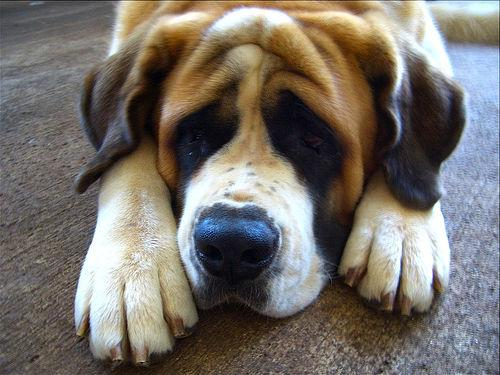

In [5]:
img = Image.open(img_file_paths[0])
img

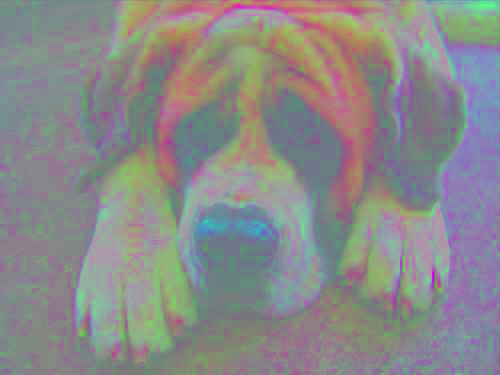

In [6]:
whiten_image(img)

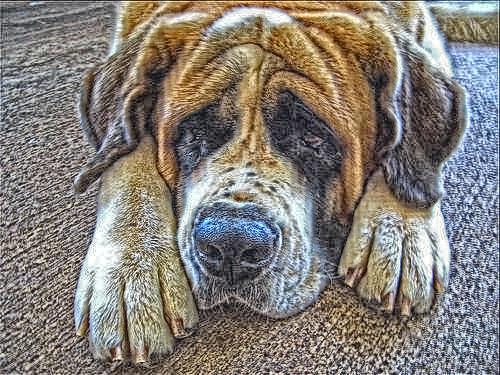

In [7]:
equalize_histogram(img, clip_limit=12.0, grid_size=(80, 80))

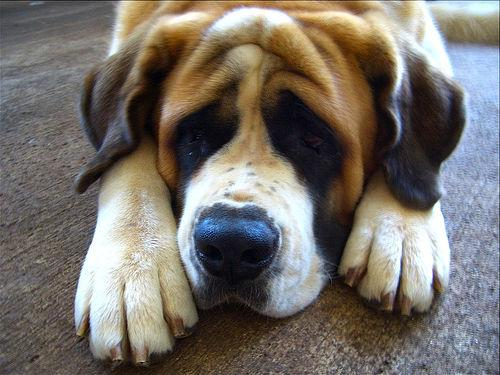

In [8]:
normalize_image(img, mean=0.0, std=1.0)

## Exemples de fonctions de *data augmentation*

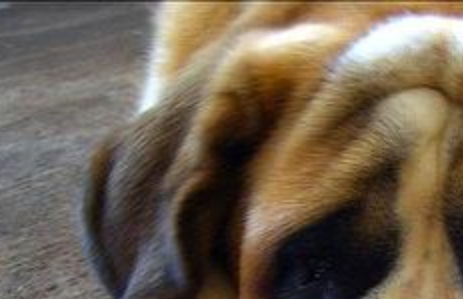

In [9]:
crop_image(
    resize_image(img, scaling_factor=(2, 2)),
    *get_boundingbox(annot_file_paths[0]),
)

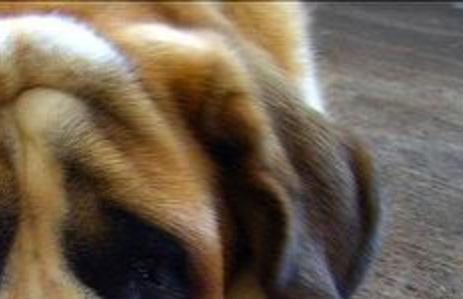

In [10]:
mirror_image(
    crop_image(
        resize_image(img, scaling_factor=(2, 2)),
        *get_boundingbox(annot_file_paths[0]),
    ),
    horizontal=True,
)